In [4]:
import pandas as pd    
import numpy as np          
import matplotlib.pyplot as plt           
from pathlib import Path

In [6]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / 'raw'
STOCK = "AAPL"
df = pd.read_csv(RAW_DATA_PATH / f"{STOCK}.csv")

In [ ]:
df.head() # Give the starting of the data from starting Date.

,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.469212,37.689872,36.593696,36.750293,148158800
1,2019-01-03,33.737003,34.574556,33.691922,34.161710,365248800
2,2019-01-04,35.177204,35.246014,34.118995,34.292199,234428400
3,2019-01-07,35.098907,35.312450,34.617256,35.281604,219111200
4,2019-01-08,35.768009,36.021887,35.238905,35.485661,164101200


In [ ]:
df.shape # Gives the size of the data frame

(1885, 6)

In [ ]:
df.columns # Gives the List of columns which is there in the data frame

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [ ]:
df.tail() # Gives the bottom part of the data frame It's like the data at the ending date or close to the ending Date.

,Date,Close,High,Low,Open,Volume
1880,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
1881,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
1882,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
1883,2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
1884,2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


In [14]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1885 non-null   str    
 1   Close   1885 non-null   float64
 2   High    1885 non-null   float64
 3   Low     1885 non-null   float64
 4   Open    1885 non-null   float64
 5   Volume  1885 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 106.9 KB


In [15]:
df.isnull().sum() # checks the Missing values

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [16]:
df.duplicated().sum() # Checks the duplicate data

0

In [ ]:
df["Date"].dtype # Checks wether the date is stored in Date-Time data set or normal text
df["Date"] = pd.to_datetime(df["Date"]) # Convert the data type into Date-Time data type
df["Date"].dtype

dtype('<M8[us]')

In [ ]:
df.set_index("Date", inplace=True)

In [27]:
df.head()
print(df.index)
print(df.columns)

DatetimeIndex(['2019-01-02', '2019-01-03', '2019-01-04', '2019-01-07',
               '2019-01-08', '2019-01-09', '2019-01-10', '2019-01-11',
               '2019-01-14', '2019-01-15',
               ...
               '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24',
               '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30',
               '2026-07-01', '2026-07-02'],
              dtype='datetime64[us]', name='Date', length=1885, freq=None)
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [28]:
df.describe()

,Close,High,Low,Open,Volume
count,1885.000000,1885.000000,1885.000000,1885.000000,1.885000e+03
mean,156.509100,158.110013,154.766691,156.360493,8.598501e+07
std,66.980533,67.601925,66.344447,66.941625,5.074714e+07
min,33.737003,34.574556,33.691922,34.161710,1.791060e+07
25%,116.859467,118.163426,115.242573,116.674586,5.100590e+07
50%,156.219879,158.911787,154.290689,156.666743,7.342080e+07
75%,202.466782,206.221849,200.165912,203.536884,1.044345e+08
max,315.200012,317.399994,309.649994,314.179993,4.265100e+08


In [29]:
print(df.index.min())
print(df.index.max())

2019-01-02 00:00:00
2026-07-02 00:00:00


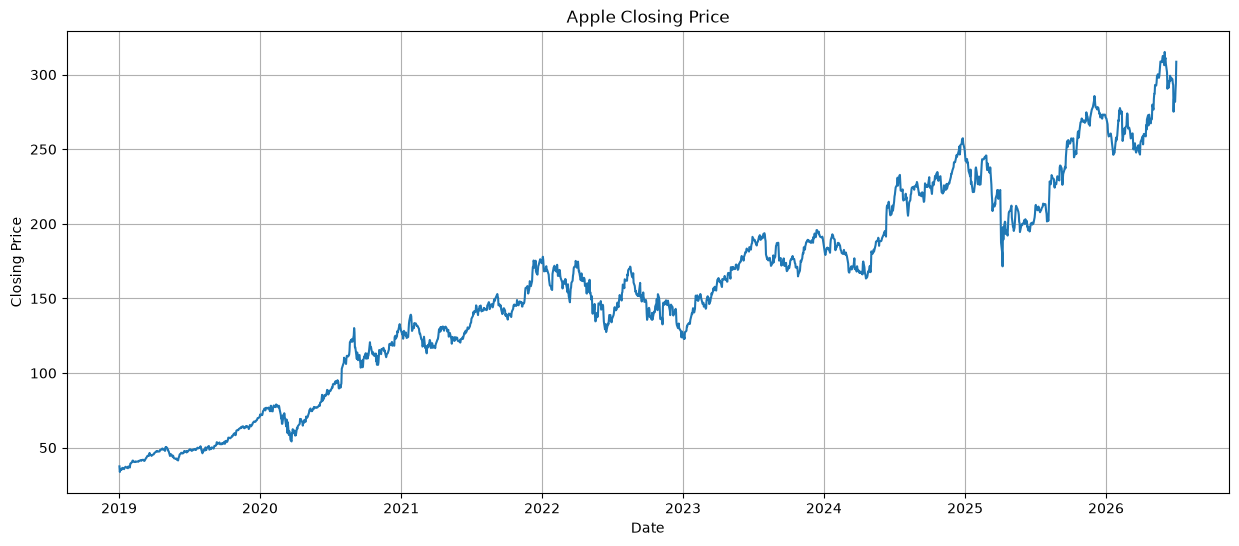

In [30]:
# How has Apple's stock price changed over time!

plt.figure(figsize=(15,6))
plt.plot(df.index, df["Close"])
plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

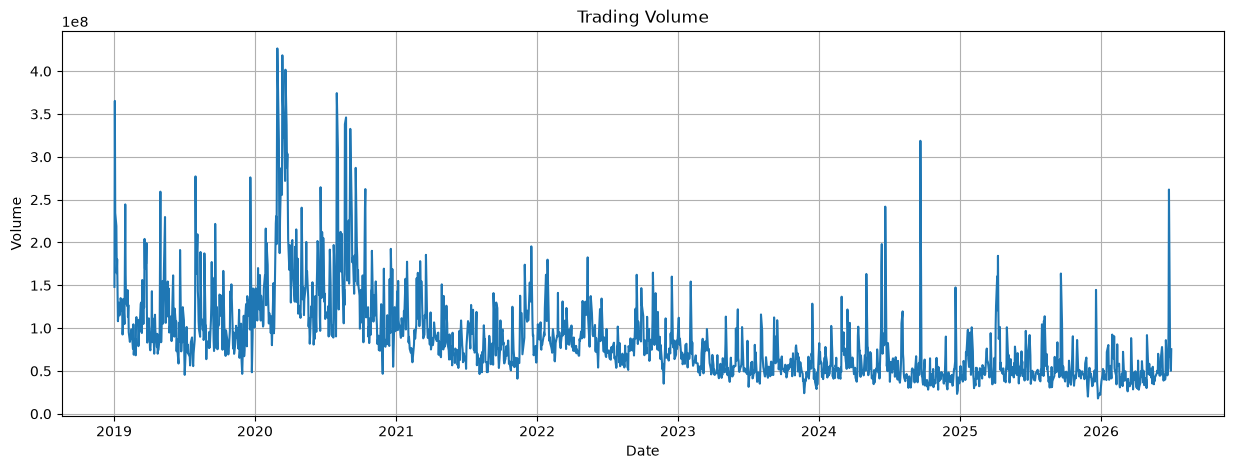

In [31]:
# How actively was the stock traded

plt.figure(figsize=(15,5))
plt.plot(df.index, df["Volume"])
plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

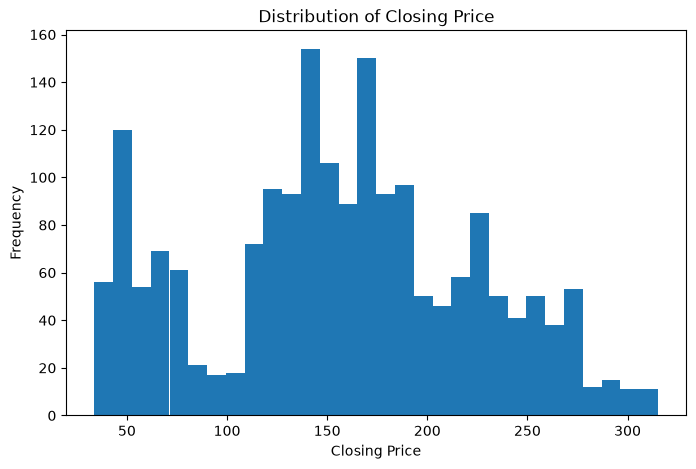

In [32]:
# How are prices distributed

plt.figure(figsize=(8,5))
plt.hist(df["Close"], bins=30)
plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

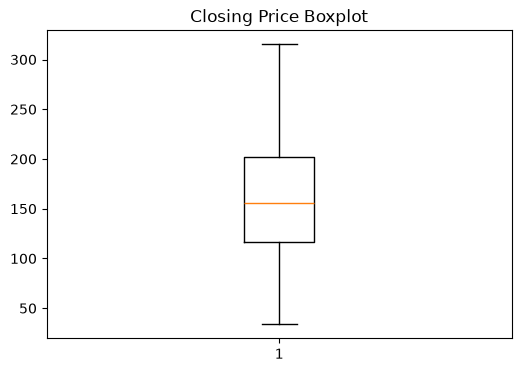

In [33]:
# Are there outliers

plt.figure(figsize=(6,4))
plt.boxplot(df["Close"])
plt.title("Closing Price Boxplot")
plt.show()

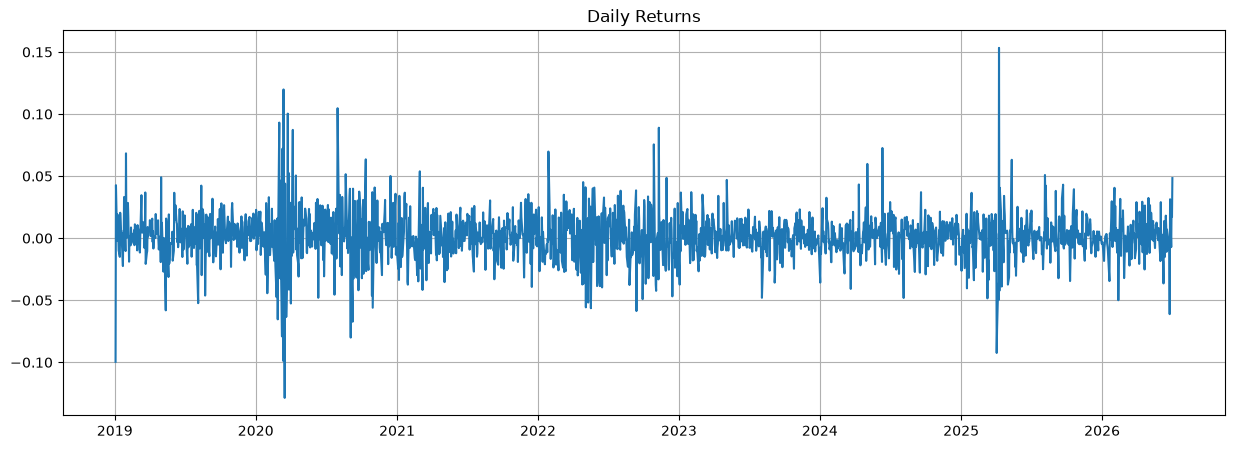

In [34]:
# Actually we created the new column of How the daily return looks like
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(15,5))
plt.plot(df.index, df["Daily_Return"])
plt.title("Daily Returns")
plt.grid(True)
plt.show()